# Solar Radiation Data Analysis: Benin, Sierra Leone, and Togo

This notebook compares solar radiation metrics (GHI, DNI, DHI) across three countries:
- Benin
- Sierra Leone
- Togo

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better visualizations
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = [12, 8]

# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
def load_country_data(country_name):
    """Load data for a specific country."""
    filename = f'../../data/{country_name.lower().replace(" ", "_")}_clean.csv'
    df = pd.read_csv(filename)
    df['Country'] = country_name
    print(f"Successfully loaded data for {country_name}")
    return df

# Load data for all countries
countries = ['Benin', 'Sierra Leone', 'Togo']
dfs = []

for country in countries:
    try:
        df = load_country_data(country)
        dfs.append(df)
    except Exception as e:
        print(f"Error loading data for {country}: {str(e)}")

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

Successfully loaded data for Benin
Successfully loaded data for Sierra Leone
Successfully loaded data for Togo


,TIMESTAMP,GHI,DNI,DHI,MODA,MODB,TAMB,RH,WS,WSGUST,WSSTDEV,WD,WDSTDEV,BP,CLEANING,PRECIPITATION,TMODA,TMODB,COMMENTS,Country
0,2021-08-09 06:54,16.7,0.0,16.5,16.1,16.3,24.2,98.8,0.0,0.0,0.0,0.0,0.0,997,0,0.0,24.2,23.7,NaN,Benin
1,2021-08-09 06:55,18.2,0.1,18.0,17.4,17.6,24.2,98.8,0.0,0.0,0.0,0.0,0.0,997,0,0.0,24.3,23.8,NaN,Benin
2,2021-08-09 06:56,19.7,0.3,19.5,18.7,18.9,24.2,98.8,0.0,0.0,0.0,0.0,0.0,997,0,0.0,24.3,23.9,NaN,Benin
3,2021-08-09 06:57,21.1,0.6,20.9,19.9,20.1,24.2,98.9,0.0,0.0,0.0,0.0,0.0,997,0,0.0,24.4,23.9,NaN,Benin
4,2021-08-09 06:58,22.5,1.1,22.2,21.1,21.3,24.2,98.9,0.0,0.0,0.0,0.0,0.0,997,0,0.0,24.5,24.0,NaN,Benin


## Distribution Analysis

Let's examine the distribution of solar radiation metrics across countries using boxplots.

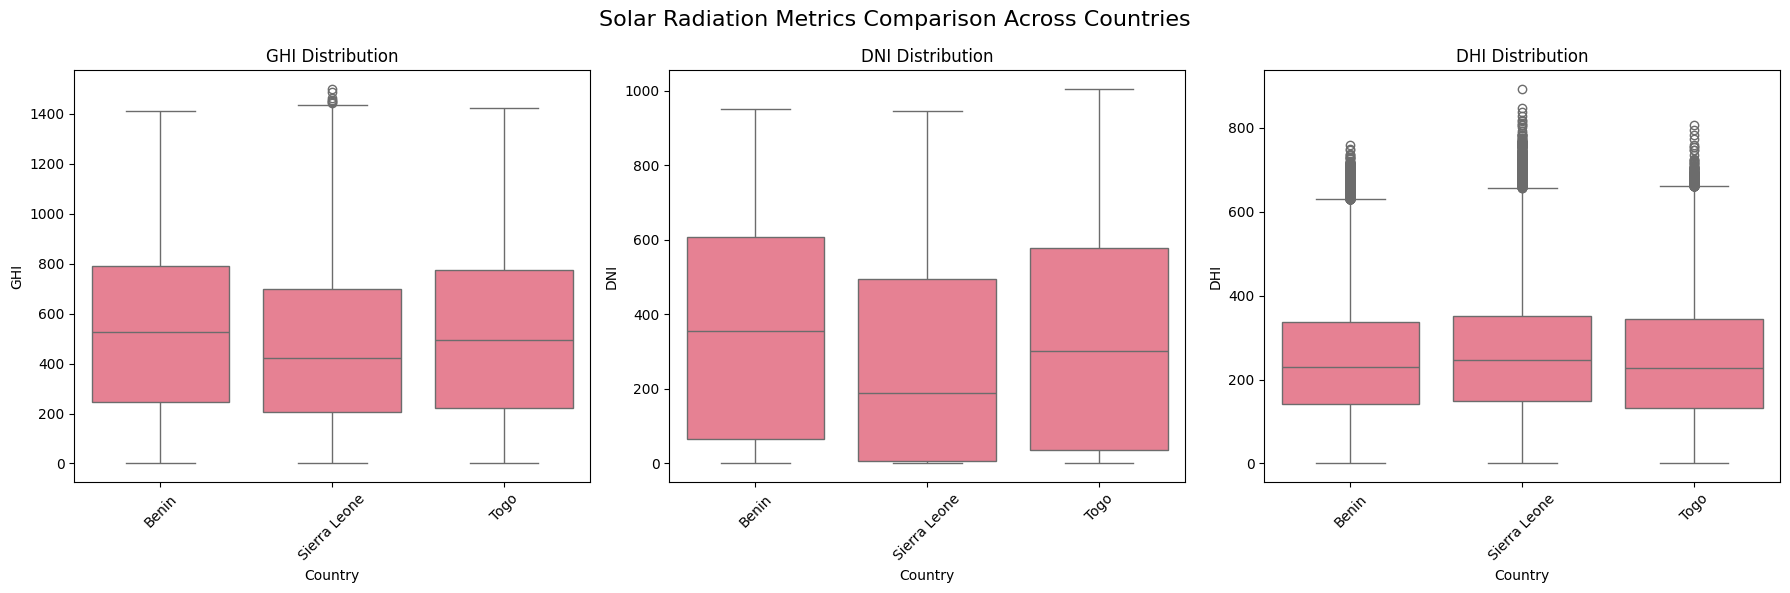

In [4]:
# Create boxplots for GHI, DNI, DHI comparison
metrics = ['GHI', 'DNI', 'DHI']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Solar Radiation Metrics Comparison Across Countries', fontsize=16)

for i, metric in enumerate(metrics):
    sns.boxplot(data=combined_df, x='Country', y=metric, ax=axes[i])
    axes[i].set_title(f'{metric} Distribution')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Statistical Analysis

Let's calculate summary statistics and perform statistical tests to compare the metrics across countries.

In [5]:
# Calculate summary statistics
summary_stats = combined_df.groupby('Country')[metrics].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


GHI                                  DNI                  \
               count    mean     std  min     max   count    mean     std   
Country                                                                     
Benin         244936  516.85  303.41  0.0  1413.0  244936  359.30  279.04   
Sierra Leone  230178  456.93  292.98  0.0  1499.0  230178  266.04  263.28   
Togo          240231  496.58  308.16  0.0  1424.0  240231  330.54  280.25   

                              DHI                              
              min     max   count    mean     std  min    max  
Country                                                        
Benin         0.0   952.3  244936  248.72  143.03  0.0  759.2  
Sierra Leone  0.0   946.0  230178  255.71  140.93  0.0  892.0  
Togo          0.0  1004.5  240231  244.04  145.89  0.0  805.7

In [6]:
# Perform Kruskal-Wallis H-test for each metric
print("Statistical Tests (Kruskal-Wallis H-test):")
for metric in metrics:
    h_stat, p_val = stats.kruskal(
        *[df[metric].values for df in dfs]
    )
    print(f"\n{metric}:")
    print(f"H-statistic: {h_stat:.2f}")
    print(f"p-value: {p_val:.4f}")

Statistical Tests (Kruskal-Wallis H-test):

GHI:
H-statistic: 5002.82
p-value: 0.0000

DNI:
H-statistic: 15049.81
p-value: 0.0000

DHI:
H-statistic: 1183.73
p-value: 0.0000


## Visualization of Mean Values

Let's create a bar plot to compare mean solar radiation values across countries.

<Figure size 1200x600 with 0 Axes>

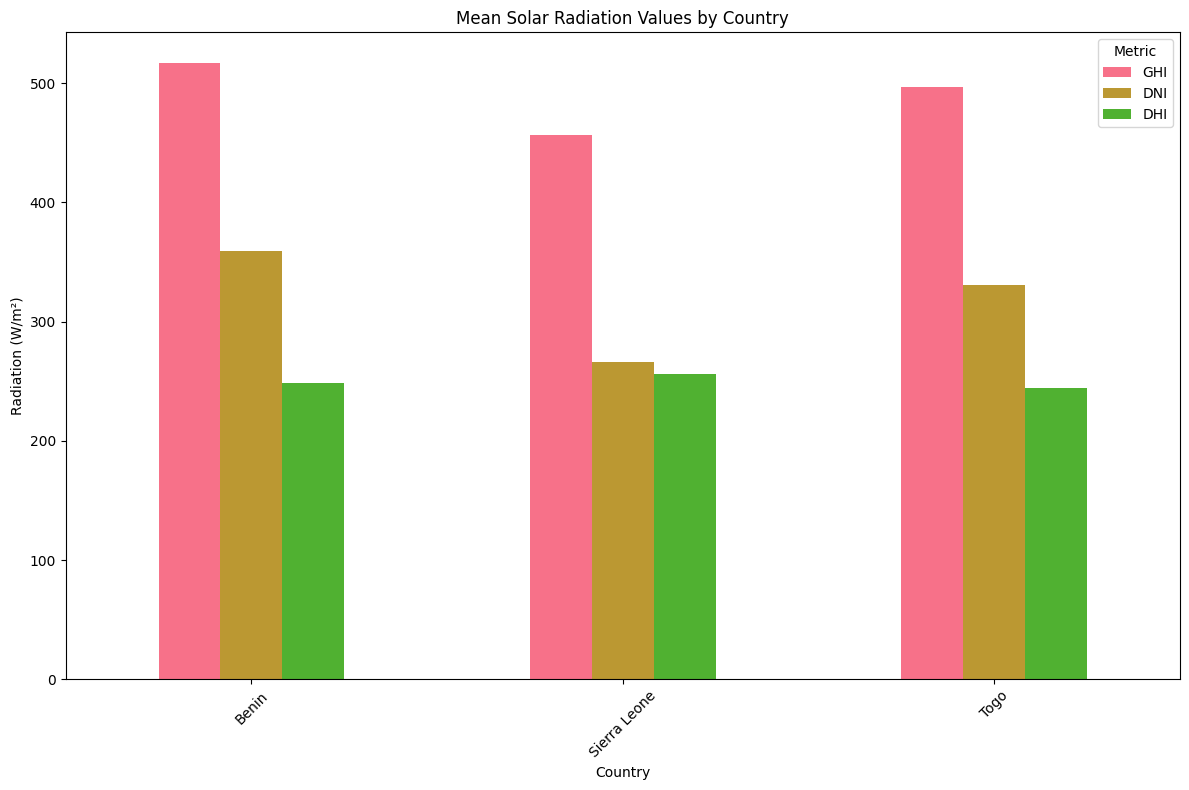


Summary statistics saved to 'data/solar_comparison_summary.csv'


In [7]:
# Create bar plots for mean values
plt.figure(figsize=(12, 6))
means = combined_df.groupby('Country')[metrics].mean()
means.plot(kind='bar', rot=45)
plt.title('Mean Solar Radiation Values by Country')
plt.ylabel('Radiation (W/m²)')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Save summary statistics to CSV
summary_stats.to_csv('../../data/solar_comparison_summary.csv')
print("\nSummary statistics saved to 'data/solar_comparison_summary.csv'")